In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load the dataset
data = pd.read_csv('dataset.csv')
# Display the first few rows of the dataset
data.head()

,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment,Diet,Recommendation
0,1,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,2,Male,18,1.68,47.5,Yes,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...
2,3,Male,18,1.68,47.5,No,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor","Vegetables: (Garlic, Roma Tomatoes, Capers and...",Follow a regular exercise schedule. Adhere to ...
3,4,Male,18,1.68,47.5,Yes,Yes,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Light athletic shoes, resistance bands, light ...","Vegetables: (Garlic, Roma Tomatoes, Capers, Gr...",Follow a regular exercise schedule. Adhere to ...
4,5,Male,18,1.68,47.5,No,No,16.83,Underweight,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, Lettuce); ...",Follow a regular exercise schedule. Adhere to ...


## Drop Unnecessary Columns


In [13]:
# drop Diet and Recommendation columns
data = data.drop(columns=['Diet', 'Recommendation'])

## Data Validation


In [14]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

# Check for duplicates
print(f"\nDuplicate rows: {data.duplicated().sum()}")

# Drop missing values and duplicates
data = data.dropna()
data = data.drop_duplicates()

print(f"\nDataset shape after cleaning: {data.shape}")

Missing values per column:
ID              0
Sex             0
Age             0
Height          0
Weight          0
Hypertension    0
Diabetes        0
BMI             0
Level           0
Fitness Goal    0
Fitness Type    0
Exercises       0
Equipment       0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Dataset shape after cleaning: (14589, 13)


## Encode Categorical Data


In [15]:
from sklearn.preprocessing import LabelEncoder

# Simpan encoder per kolom untuk inferensi nanti
label_encoders = {}

# encode specified columns 'Sex', 'Hypertension', 'Diabetes', 'Fitness Goal', 'Fitness Type'
for column in ['Sex', 'Hypertension', 'Diabetes', 'Fitness Goal', 'Fitness Type']:
	le = LabelEncoder()
	data[column] = le.fit_transform(data[column])
	label_encoders[column] = le

# encode 'Level' column with custom mapping
# Periksa nilai unik terlebih dahulu
print("Unique values in Level column:", data['Level'].unique())

level_mapping = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3, 'Obuse': 3}  # support typo
data['Level'] = data['Level'].map(level_mapping)

# Cek jika ada nilai yang tidak ter-map
if data['Level'].isnull().sum() > 0:
	print(f"Warning: {data['Level'].isnull().sum()} rows dengan Level tidak valid")
	data = data.dropna(subset=['Level'])

data.head()

Unique values in Level column: ['Underweight' 'Normal' 'Overweight' 'Obuse']


,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment
0,1,1,18,1.68,47.5,0,0,16.83,0,0,1,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells
1,2,1,18,1.68,47.5,1,0,16.83,0,0,1,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li..."
2,3,1,18,1.68,47.5,0,1,16.83,0,0,1,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor"
3,4,1,18,1.68,47.5,1,1,16.83,0,0,1,"Squats, yoga, deadlifts, bench presses, and ov...","Light athletic shoes, resistance bands, light ..."
4,5,1,18,1.68,47.5,0,0,16.83,0,0,1,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells


## Normalize Data


In [16]:
from sklearn.preprocessing import StandardScaler
# normalize ONLY continuous numerical columns (Age, Height, Weight, BMI)
# DO NOT normalize categorical/ordinal columns (Sex, Level, Fitness Goal, Fitness Type)
scaler = StandardScaler()
data[['Age', 'Height', 'Weight', 'BMI']] = scaler.fit_transform(data[['Age', 'Height', 'Weight', 'BMI']])
data.head()

,ID,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Fitness Goal,Fitness Type,Exercises,Equipment
0,1,1,-1.63391,-0.202298,-1.14858,0,0,-1.121606,0,0,1,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells
1,2,1,-1.63391,-0.202298,-1.14858,1,0,-1.121606,0,0,1,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li..."
2,3,1,-1.63391,-0.202298,-1.14858,0,1,-1.121606,0,0,1,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor"
3,4,1,-1.63391,-0.202298,-1.14858,1,1,-1.121606,0,0,1,"Squats, yoga, deadlifts, bench presses, and ov...","Light athletic shoes, resistance bands, light ..."
4,5,1,-1.63391,-0.202298,-1.14858,0,0,-1.121606,0,0,1,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells


In [17]:
# === MODEL: Multi-output classifier for Exercises & Equipment ===
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import joblib

# Fitur dan label
feature_cols = ['Sex','Age','Height','Weight','Hypertension','Diabetes','BMI','Level','Fitness Goal','Fitness Type']
X = data[feature_cols].values

# Encode target labels
le_ex = LabelEncoder().fit(data['Exercises'])
le_eq = LabelEncoder().fit(data['Equipment'])
y_ex = le_ex.transform(data['Exercises'])
y_eq = le_eq.transform(data['Equipment'])
y = np.column_stack([y_ex, y_eq])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

# Model dasar
base = RandomForestClassifier(
	n_estimators=300,
	class_weight='balanced_subsample',
	n_jobs=-1,
	random_state=42
)
clf = MultiOutputClassifier(base)

# Train
clf.fit(X_train, y_train)

# Evaluasi
y_pred = clf.predict(X_test)
acc_ex = accuracy_score(y_test[:,0], y_pred[:,0])
acc_eq = accuracy_score(y_test[:,1], y_pred[:,1])
f1_ex = f1_score(y_test[:,0], y_pred[:,0], average='macro')
f1_eq = f1_score(y_test[:,1], y_pred[:,1], average='macro')
subset_acc = np.mean(np.all(y_pred == y_test, axis=1))
# sklearn.metrics.hamming_loss doesn't support multiclass-multioutput; compute manually
hamm = np.mean(y_test != y_pred)

print(f"Exercises  - Acc: {acc_ex:.3f} | F1-macro: {f1_ex:.3f}")
print(f"Equipment  - Acc: {acc_eq:.3f} | F1-macro: {f1_eq:.3f}")
print(f"Subset accuracy (both correct): {subset_acc:.3f}")
print(f"Hamming loss: {hamm:.3f}")


Exercises  - Acc: 0.998 | F1-macro: 0.998
Equipment  - Acc: 0.954 | F1-macro: 0.908
Subset accuracy (both correct): 0.954
Hamming loss: 0.024


## Cross-Validation


In [18]:
# Cross-validation untuk validasi model lebih robust
from sklearn.model_selection import cross_val_score

print("Melakukan 5-fold Cross-Validation...")

# CV untuk Exercises (output pertama)
cv_scores_ex = cross_val_score(
	RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
	X_train, 
	y_train[:,0], 
	cv=5, 
	scoring='accuracy'
)

# CV untuk Equipment (output kedua)
cv_scores_eq = cross_val_score(
	RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
	X_train, 
	y_train[:,1], 
	cv=5, 
	scoring='accuracy'
)

print(f"\nCross-Validation Results (5-fold):")
print(f"Exercises  - Mean: {cv_scores_ex.mean():.3f} ± {cv_scores_ex.std():.3f}")
print(f"             Scores: {cv_scores_ex}")
print(f"\nEquipment  - Mean: {cv_scores_eq.mean():.3f} ± {cv_scores_eq.std():.3f}")
print(f"             Scores: {cv_scores_eq}")

Melakukan 5-fold Cross-Validation...

Cross-Validation Results (5-fold):
Exercises  - Mean: 0.998 ± 0.001
             Scores: [0.99828694 0.9982862  0.99785775 0.99785775 0.99657241]

Equipment  - Mean: 0.941 ± 0.004
             Scores: [0.94261242 0.93744644 0.94044559 0.93573265 0.94687232]

Cross-Validation Results (5-fold):
Exercises  - Mean: 0.998 ± 0.001
             Scores: [0.99828694 0.9982862  0.99785775 0.99785775 0.99657241]

Equipment  - Mean: 0.941 ± 0.004
             Scores: [0.94261242 0.93744644 0.94044559 0.93573265 0.94687232]


In [19]:

# Top-K rekomendasi per label
def top_k_recommendations(model, X_row, k=3):
	out = {}
	# Exercises
	est_ex = model.estimators_[0]
	if hasattr(est_ex, "predict_proba"):
		proba_ex = est_ex.predict_proba([X_row])[0]
		idx_ex = np.argsort(proba_ex)[::-1][:k]
		out["Exercises_topK"] = le_ex.inverse_transform(idx_ex).tolist()
	else:
		out["Exercises_topK"] = [le_ex.inverse_transform([est_ex.predict([X_row])[0]])[0]]
	# Equipment
	est_eq = model.estimators_[1]
	if hasattr(est_eq, "predict_proba"):
		proba_eq = est_eq.predict_proba([X_row])[0]
		idx_eq = np.argsort(proba_eq)[::-1][:k]
		out["Equipment_topK"] = le_eq.inverse_transform(idx_eq).tolist()
	else:
		out["Equipment_topK"] = [le_eq.inverse_transform([est_eq.predict([X_row])[0]])[0]]
	return out

# Contoh top-3 untuk sampel pertama test
example_rec = top_k_recommendations(clf, X_test[0], k=3)
print("Top-3:", example_rec)


Top-3: {'Exercises_topK': ['Brisk walking, cycling, swimming, running , or dancing.', 'brisk walking, cycling, swimming, or dancing.', 'Walking, Yoga, Swimming.'], 'Equipment_topK': ['Ellipticals, Indoor Rowers,Treadmills, and Rowing machine', 'Ellipticals, Indoor Rowers,Treadmills, Rowing machine', 'Light athletic shoes, resistance bands, light dumbbells and a Blood glucose monitor.']}
 {'Exercises_topK': ['Brisk walking, cycling, swimming, running , or dancing.', 'brisk walking, cycling, swimming, or dancing.', 'Walking, Yoga, Swimming.'], 'Equipment_topK': ['Ellipticals, Indoor Rowers,Treadmills, and Rowing machine', 'Ellipticals, Indoor Rowers,Treadmills, Rowing machine', 'Light athletic shoes, resistance bands, light dumbbells and a Blood glucose monitor.']}


In [20]:
# Simpan artefak untuk inferensi
artifacts = {
	"model": clf,
	"feature_cols": feature_cols,
	"scaler": scaler,
	"label_encoders": label_encoders,  # encoder untuk fitur kategorikal
	"level_mapping": level_mapping,    # mapping untuk Level
	"le_exercises": le_ex,
	"le_equipment": le_eq,
}
joblib.dump(artifacts, "recommender.joblib")
print("Model dan artifacts berhasil disimpan ke 'recommender.joblib'")

Model dan artifacts berhasil disimpan ke 'recommender.joblib'


## Feature Importance Analysis



Exercises - Top Features:
        Feature  Importance
5      Diabetes    0.437802
4  Hypertension    0.214771
6           BMI    0.097767
9  Fitness Type    0.079719
7         Level    0.070578
8  Fitness Goal    0.067478
3        Weight    0.023867
2        Height    0.003632
1           Age    0.002958
0           Sex    0.001427


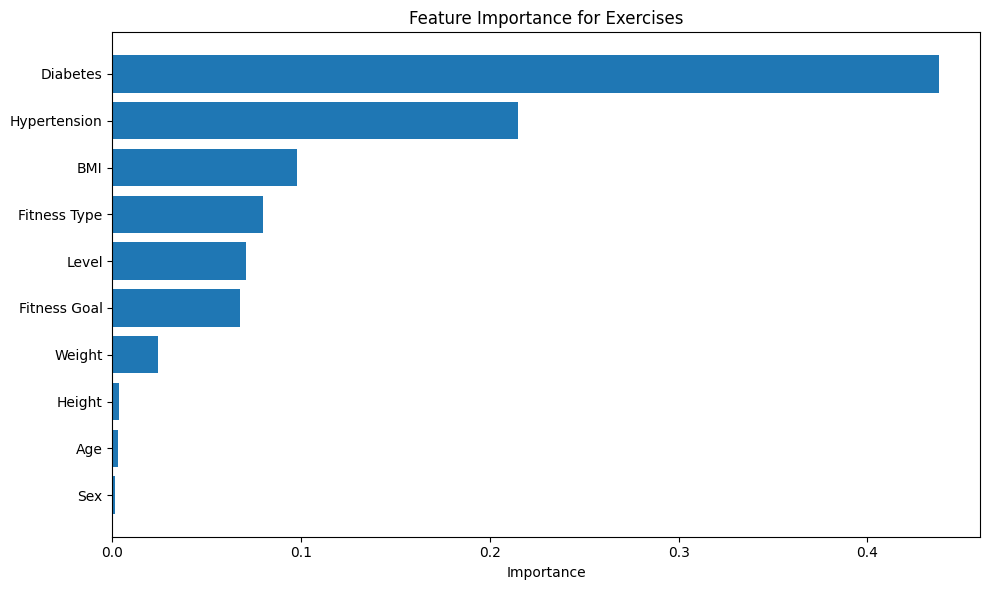


Equipment - Top Features:
        Feature  Importance
5      Diabetes    0.268895
4  Hypertension    0.249719
1           Age    0.133920
6           BMI    0.113045
2        Height    0.058133
3        Weight    0.056909
9  Fitness Type    0.033560
7         Level    0.031585
8  Fitness Goal    0.027955
0           Sex    0.026279


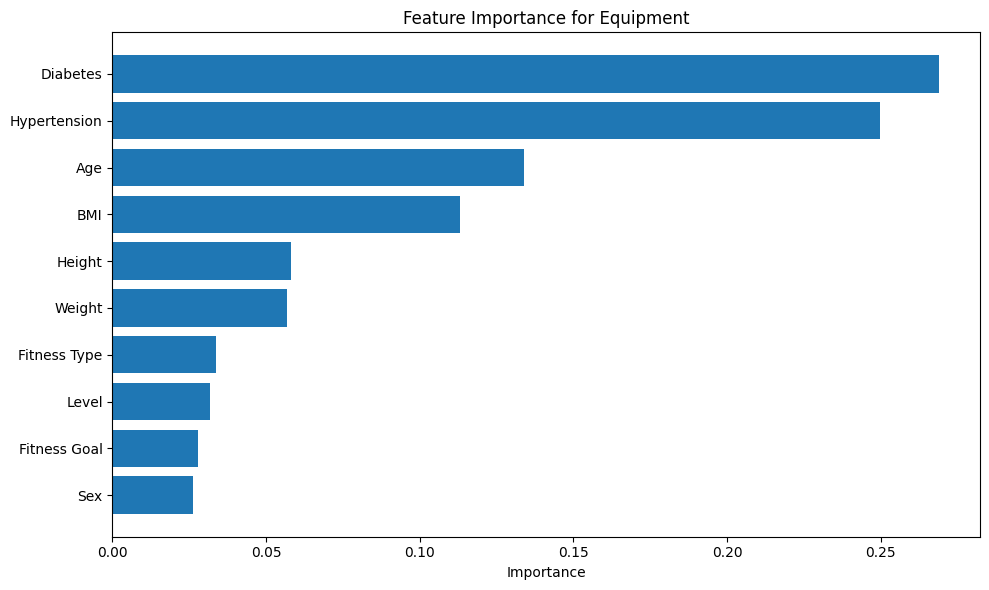

In [21]:
# Analisis feature importance untuk setiap output
import pandas as pd

for i, target in enumerate(['Exercises', 'Equipment']):
	imp = clf.estimators_[i].feature_importances_
	imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': imp})
	imp_df = imp_df.sort_values('Importance', ascending=False)
	print(f"\n{target} - Top Features:")
	print(imp_df)
	
	# Visualisasi
	plt.figure(figsize=(10, 6))
	plt.barh(imp_df['Feature'], imp_df['Importance'])
	plt.xlabel('Importance')
	plt.title(f'Feature Importance for {target}')
	plt.gca().invert_yaxis()
	plt.tight_layout()
	plt.show()

## Inference Function for New Users


In [ ]:
def predict_new_user(user_dict, artifacts):
	"""
	Fungsi untuk memprediksi rekomendasi untuk user baru
	
	Parameters:
	user_dict: dict dengan keys ['Sex', 'Age', 'Height', 'Weight', 'Hypertension', 
	                              'Diabetes', 'BMI', 'Level', 'Fitness Goal', 'Fitness Type']
	artifacts: dict hasil load dari recommender.joblib
	
	Returns:
	dict dengan Top-K recommendations untuk Exercises dan Equipment
	"""
	df = pd.DataFrame([user_dict])
	
	# Validasi nilai kategorikal
	for col, le in artifacts['label_encoders'].items():
		if col in df.columns:
			valid_values = le.classes_
			actual_value = df[col].iloc[0]
			if actual_value not in valid_values:
				raise ValueError(f"Invalid value '{actual_value}' for {col}. Valid values: {valid_values}")
			df[col] = le.transform(df[col])
	
	# Map Level menggunakan saved mapping
	level_value = df['Level'].iloc[0]
	if level_value not in artifacts['level_mapping']:
		raise ValueError(f"Invalid Level '{level_value}'. Valid values: {list(artifacts['level_mapping'].keys())}")
	df['Level'] = df['Level'].map(artifacts['level_mapping'])
	
	# Scale kolom numerik menggunakan saved scaler
	num_cols = ['Age', 'Height', 'Weight', 'BMI']
	df[num_cols] = artifacts['scaler'].transform(df[num_cols])
	
	# Predict
	X_new = df[artifacts['feature_cols']].values
	return top_k_recommendations(artifacts['model'], X_new[0], k=3)

# CONTOH: Gunakan nilai dari dataset yang sebenarnya
# Jalankan sel sebelumnya untuk melihat nilai valid, lalu sesuaikan test_user
# Untuk sementara, kita ambil contoh dari data training
sample_idx = 0
test_user_from_data = data.iloc[sample_idx][['Sex', 'Age', 'Height', 'Weight', 'Hypertension', 
                                               'Diabetes', 'BMI', 'Level', 'Fitness Goal', 'Fitness Type']].to_dict()

print("Contoh user dari dataset (sudah encoded):")
print(test_user_from_data)

# Untuk test dengan data baru, gunakan nilai yang SAMA dengan yang ada di training data
# Contoh struktur (sesuaikan dengan output sel sebelumnya):
# test_user = {
# 	'Sex': 'Male',  # atau 'Female' sesuai data
# 	'Age': 30, 
# 	'Height': 175, 
# 	'Weight': 75,
# 	'Hypertension': 'No',  # atau 'Yes'
# 	'Diabetes': 'No',       # atau 'Yes'
# 	'BMI': 24.5,
# 	'Level': 'Normal',      # Underweight, Normal, Overweight, Obese
# 	'Fitness Goal': '<nilai_valid_dari_dataset>',
# 	'Fitness Type': '<nilai_valid_dari_dataset>'
# }

ValueError: y contains previously unseen labels: 'Cardio'

## Check Unique Values for Testing


In [ ]:
# Periksa nilai unik untuk setiap kolom kategorikal
print("Nilai unik untuk setiap fitur kategorikal:\n")
for col in ['Sex', 'Hypertension', 'Diabetes', 'Fitness Goal', 'Fitness Type']:
	if col in label_encoders:
		print(f"{col}: {label_encoders[col].classes_}")
	
print(f"\nLevel mapping: {level_mapping}")
print(f"\nExercises: {le_ex.classes_[:10]}... (showing first 10)")
print(f"Equipment: {le_eq.classes_[:10]}... (showing first 10)")